## Basic Analysis

### Mismatch Proxy

We define a **rating-anchored mismatch proxy** to operationalize the directional divergence between product descriptions and reviews. Specifically, we train two separate regressors mapping description embeddings and review embeddings respectively to user ratings. The mismatch score for item i is defined as $M_i = \hat{y}_i^{desc} - \hat{y}_i^{rev}$​, where positive values indicate over-description (the description implies higher quality than the review reflects) and negative values indicate under-description. This formulation treats user rating as a shared anchor that projects both modalities into a common evaluative space, enabling directional comparison across heterogeneous embedding representations.

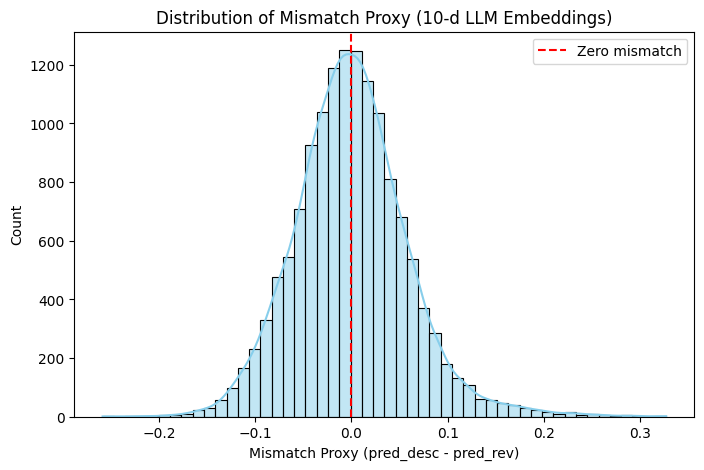

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Example for llm (10-d) embeddings
df = pd.read_csv("../Mismatch_Score/llm_mismatch_score.csv")

plt.figure(figsize=(8,5))
sns.histplot(df['mismatch_proxy'], bins=50, kde=True, color='skyblue')
plt.axvline(0, color='red', linestyle='--', label='Zero mismatch')
plt.xlabel("Mismatch Proxy (pred_desc - pred_rev)")
plt.ylabel("Count")
plt.title("Distribution of Mismatch Proxy (10-d LLM Embeddings)")
plt.legend()
plt.show()r


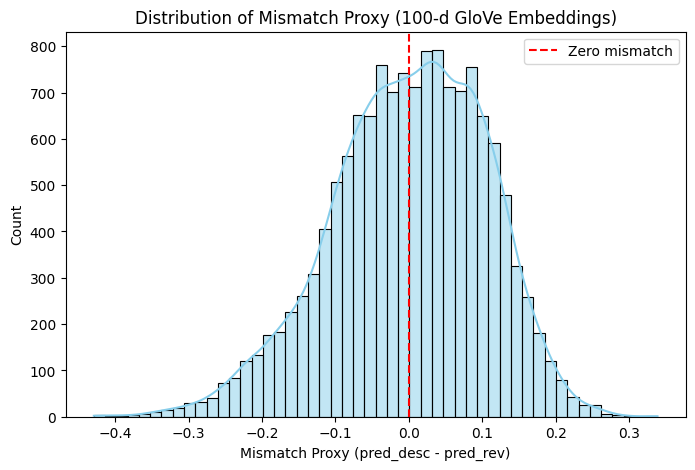

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example for glove (100-d) embeddings
df = pd.read_csv("../Mismatch_Score/baseline_mismatch_score.csv")

plt.figure(figsize=(8,5))
sns.histplot(df['mismatch_proxy'], bins=50, kde=True, color='skyblue')
plt.axvline(0, color='red', linestyle='--', label='Zero mismatch')
plt.xlabel("Mismatch Proxy (pred_desc - pred_rev)")
plt.ylabel("Count")
plt.title("Distribution of Mismatch Proxy (100-d GloVe Embeddings)")
plt.legend()
plt.show()


We observed that a positive mismatch proxy (mismatch_proxy > 0) does not necessarily correspond to cases where users give low ratings despite an overly positive description. Instead, it reflects instances where, according to the model, the description implies a higher expected rating than the review does. In other words, the proxy measures the relative discrepancy as learned by the embeddings, not the raw user dissatisfaction.

To identify the more traditional “over-promise leading to low ratings” cases, we would need to combine the mismatch proxy with a filter on actual ratings, for example selecting only rows with rating < 4.0. This ensures that the proxy highlights situations where the description oversells the product and the user experience is genuinely lower.

### Mismatch Score

It is worth noting that this proxy measure captures mismatch as reflected in user satisfaction rather than pure semantic divergence. Cases where description and review emphasize different product aspects but converge on similar satisfaction levels may be underrepresented by this metric. We therefore complement the main experiment with a dimension-level analysis on the 10-dimensional semantic space, which directly quantifies per-dimension divergence independent of rating supervision.

In [3]:
import statsmodels.api as sm

output_student_csv = "../Mismatch_Score/llm_mismatch_score.csv"
df = pd.read_csv(output_student_csv)

# -----------------------------
# 3. Regression: rating ~ mover + munder
# -----------------------------
X = df[['mover', 'munder']]
X = sm.add_constant(X)  # add intercept
y = df['rating']


model = sm.OLS(y, X).fit()
print("=== Regression Results: rating ~ mover + munder ===")
print(model.summary())

=== Regression Results: rating ~ mover + munder ===
                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     262.3
Date:                Wed, 11 Feb 2026   Prob (F-statistic):          1.45e-112
Time:                        18:55:43   Log-Likelihood:                 7244.1
No. Observations:               13950   AIC:                        -1.448e+04
Df Residuals:                   13947   BIC:                        -1.446e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------


delta_S01: mean=-0.0742, std=0.1550, min=-0.6587, max=0.8532, % > 0 (over): 31.5%, % < 0 (under): 68.5%
delta_S02: mean=-0.0132, std=0.1491, min=-0.5752, max=0.8440, % > 0 (over): 44.1%, % < 0 (under): 55.9%
delta_S03: mean=-0.0978, std=0.1493, min=-0.5242, max=0.5903, % > 0 (over): 30.0%, % < 0 (under): 70.0%
delta_S04: mean=0.0174, std=0.1450, min=-0.5726, max=0.8538, % > 0 (over): 53.9%, % < 0 (under): 46.1%
delta_S05: mean=-0.0092, std=0.0603, min=-0.3442, max=0.5291, % > 0 (over): 39.6%, % < 0 (under): 60.4%
delta_S06: mean=0.0091, std=0.1221, min=-0.6095, max=0.8200, % > 0 (over): 51.8%, % < 0 (under): 48.2%
delta_S07: mean=-0.0085, std=0.1480, min=-0.6453, max=0.8293, % > 0 (over): 45.1%, % < 0 (under): 54.9%
delta_S08: mean=-0.0733, std=0.1543, min=-0.4863, max=0.6800, % > 0 (over): 35.1%, % < 0 (under): 64.9%
delta_S09: mean=-0.0111, std=0.1060, min=-0.5101, max=0.6734, % > 0 (over): 46.0%, % < 0 (under): 54.0%
delta_S10: mean=0.0024, std=0.1138, min=-0.4738, max=0.8253, % > 0

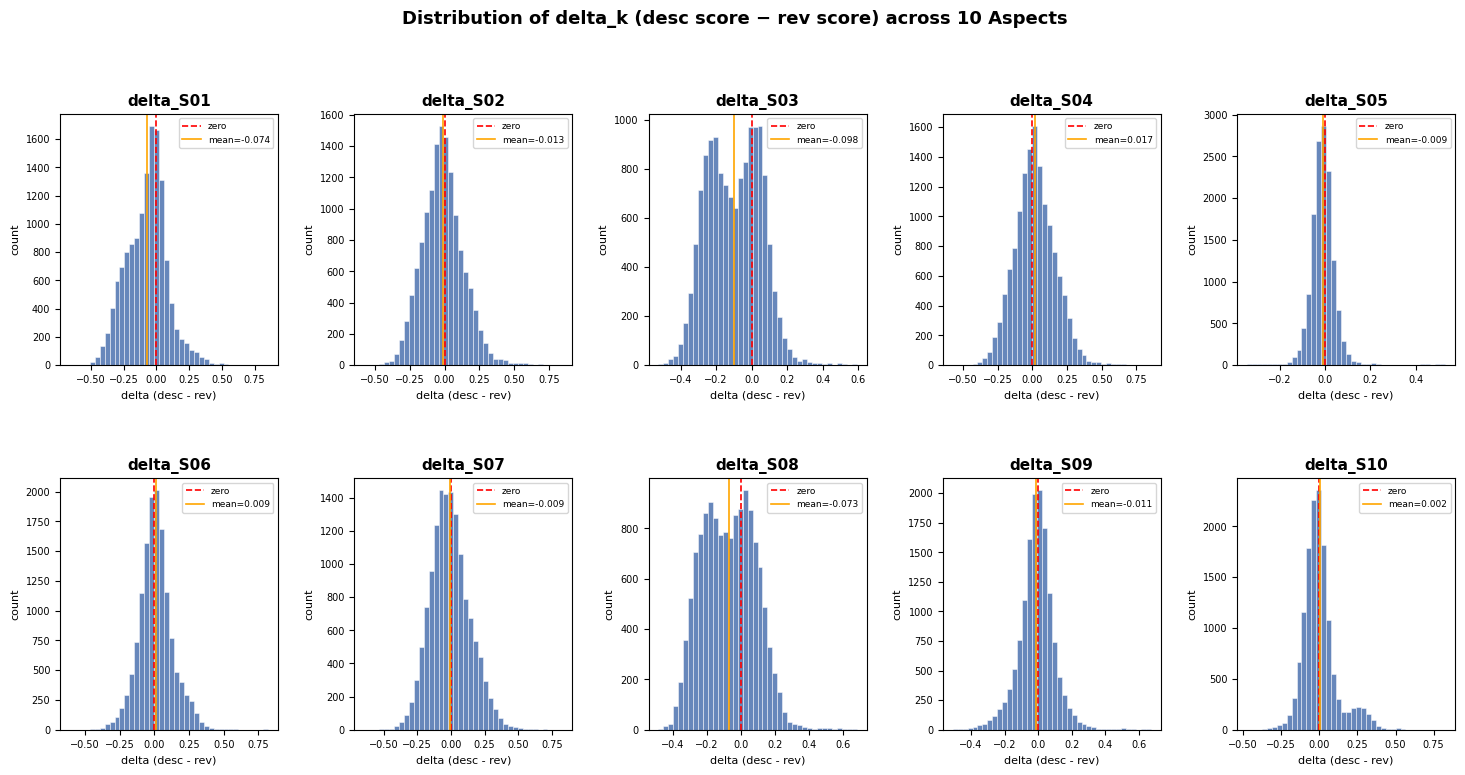

In [ ]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# --------------------------
# Load data
# --------------------------
df = pd.read_csv("../Mismatch_Score/llm_mismatch_score.csv")

delta_cols = [f"delta_S{i:02d}" for i in range(1, 11)]

# --------------------------
# Plot: 10 subplots in a 2x5 grid
# --------------------------
fig = plt.figure(figsize=(18, 8))
gs = gridspec.GridSpec(2, 5, hspace=0.45, wspace=0.35)

for idx, col in enumerate(delta_cols):
    ax = fig.add_subplot(gs[idx // 5, idx % 5])
    data = df[col].dropna()

    ax.hist(data, bins=40, color="#4C72B0", edgecolor="white", linewidth=0.4, alpha=0.85)
    ax.axvline(0, color="red", linewidth=1.2, linestyle="--", label="zero")
    ax.axvline(data.mean(), color="orange", linewidth=1.2, linestyle="-", label=f"mean={data.mean():.3f}")

    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("delta (desc - rev)", fontsize=8)
    ax.set_ylabel("count", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6.5)

    # Print stats to console
    print(f"{col}: mean={data.mean():.4f}, std={data.std():.4f}, "
          f"min={data.min():.4f}, max={data.max():.4f}, "
          f"% > 0 (over): {(data > 0).mean()*100:.1f}%, "
          f"% < 0 (under): {(data < 0).mean()*100:.1f}%")

fig.suptitle("Distribution of delta_k (desc score − rev score) across 10 Aspects",
             fontsize=13, fontweight="bold", y=1.01)

plt.show()

Total listings (>=3 reviews): 272

Top 10 listings by mabs_mean (highest overall mismatch):
                     review_count  proxy_mean  mabs_mean  mover_mean  munder_mean  rating_mean
listing_id                                                                                    
813640070361665090              6     -0.1114     0.2382      0.0292       0.2091         4.75
938431811499141903             15     -0.0964     0.2370      0.0482       0.1888         4.98
942750363293463100             16     -0.1347     0.2346      0.0343       0.2003         4.95
1481869272871304149             3      0.0925     0.2337      0.2127       0.0210         4.14
938421117122010799             11     -0.0253     0.2264      0.0845       0.1419         4.85
30189794                       40      0.1724     0.2078      0.0472       0.1606         4.95
888859204851381094              5      0.0209     0.2045      0.1063       0.0981         4.19
1454413975547667690             4      0.0745     0.2

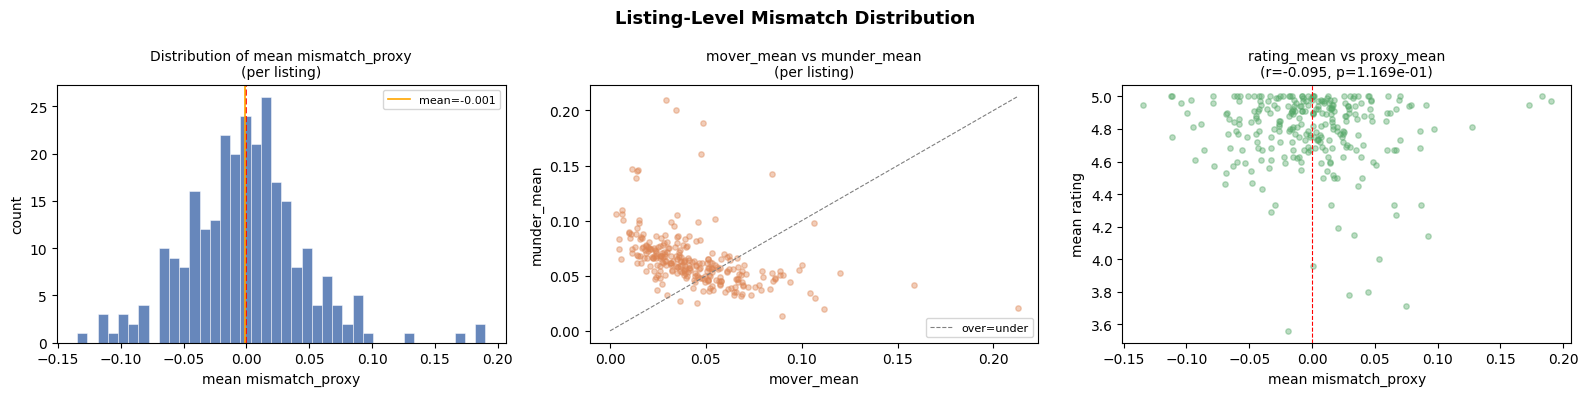

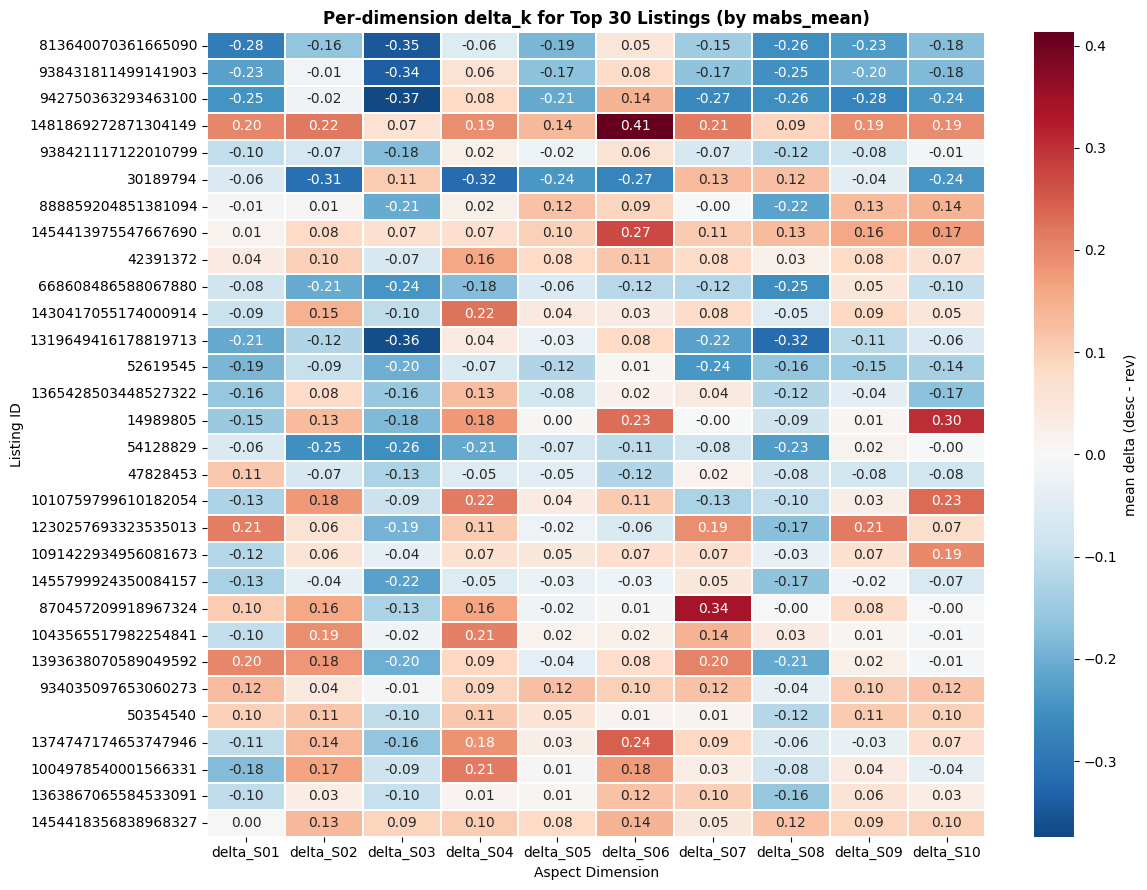

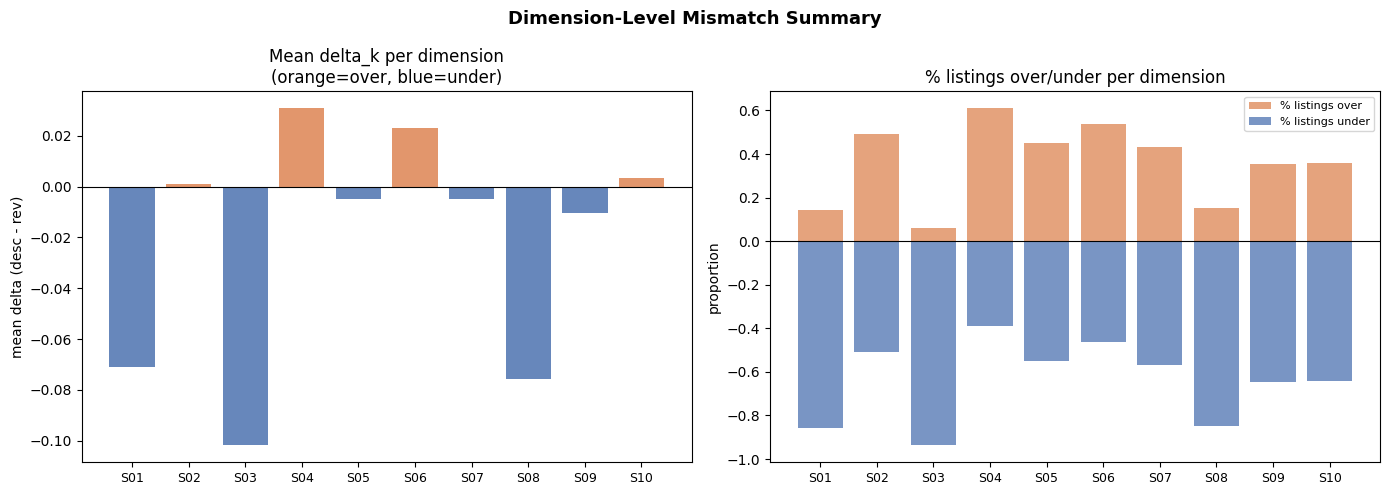

In [ ]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# --------------------------
# Load data
# --------------------------
df = pd.read_csv("../Mismatch_Score/llm_mismatch_score.csv")

delta_cols        = [f"delta_S{i:02d}" for i in range(1, 11)]
desc_score_cols   = [f"desc_S{i:02d}_score" for i in range(1, 11)]
rev_score_cols    = [f"rev_S{i:02d}_score"  for i in range(1, 11)]

# --------------------------
# 1. Listing-level aggregation
# --------------------------
agg_dict = {
    "mismatch_proxy": ["mean", "std", "count"],
    "mabs":           ["mean"],
    "mover":          ["mean"],
    "munder":         ["mean"],
    "rating":         ["mean"],
}
for col in delta_cols:
    agg_dict[col] = ["mean"]

listing_agg = df.groupby("listing_id").agg(agg_dict)
listing_agg.columns = ["_".join(c).strip() for c in listing_agg.columns]
listing_agg = listing_agg.rename(columns={
    "mismatch_proxy_mean":  "proxy_mean",
    "mismatch_proxy_std":   "proxy_std",
    "mismatch_proxy_count": "review_count",
    "mabs_mean":            "mabs_mean",
    "mover_mean":           "mover_mean",
    "munder_mean":          "munder_mean",
    "rating_mean":          "rating_mean",
})

# Rename delta mean cols for clarity
for i in range(1, 11):
    old = f"delta_S{i:02d}_mean"
    new = f"delta_S{i:02d}_mean"
    # already correct format, just ensure consistent naming
    listing_agg = listing_agg.rename(columns={old: f"delta_S{i:02d}"})

# Over/under ratio per listing
over_ratio  = df.groupby("listing_id")["mismatch_proxy"].apply(lambda x: (x > 0).mean())
under_ratio = df.groupby("listing_id")["mismatch_proxy"].apply(lambda x: (x < 0).mean())
listing_agg["over_ratio"]  = over_ratio
listing_agg["under_ratio"] = under_ratio

# Filter to listings with at least 3 reviews for stability
listing_agg = listing_agg[listing_agg["review_count"] >= 3].copy()

print(f"Total listings (>=3 reviews): {len(listing_agg)}")
print(f"\nTop 10 listings by mabs_mean (highest overall mismatch):")
print(listing_agg.nlargest(10, "mabs_mean")[
    ["review_count", "proxy_mean", "mabs_mean", "mover_mean", "munder_mean", "rating_mean"]
].round(4).to_string())

print(f"\nTop 10 listings by proxy_mean (most over-describing):")
print(listing_agg.nlargest(10, "proxy_mean")[
    ["review_count", "proxy_mean", "mabs_mean", "over_ratio", "rating_mean"]
].round(4).to_string())

print(f"\nTop 10 listings by proxy_mean (most under-describing):")
print(listing_agg.nsmallest(10, "proxy_mean")[
    ["review_count", "proxy_mean", "mabs_mean", "under_ratio", "rating_mean"]
].round(4).to_string())

# --------------------------
# 2. Overall mismatch_proxy distribution across listings
# --------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Listing-Level Mismatch Distribution", fontsize=13, fontweight="bold")

# 2a. Distribution of listing-level mean proxy
axes[0].hist(listing_agg["proxy_mean"], bins=40, color="#4C72B0",
             edgecolor="white", linewidth=0.4, alpha=0.85)
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.2)
axes[0].axvline(listing_agg["proxy_mean"].mean(), color="orange",
                linestyle="-", linewidth=1.2,
                label=f'mean={listing_agg["proxy_mean"].mean():.3f}')
axes[0].set_title("Distribution of mean mismatch_proxy\n(per listing)", fontsize=10)
axes[0].set_xlabel("mean mismatch_proxy")
axes[0].set_ylabel("count")
axes[0].legend(fontsize=8)

# 2b. mover vs munder scatter
axes[1].scatter(listing_agg["mover_mean"], listing_agg["munder_mean"],
                alpha=0.4, s=15, color="#DD8452")
axes[1].plot([0, listing_agg[["mover_mean","munder_mean"]].max().max()],
             [0, listing_agg[["mover_mean","munder_mean"]].max().max()],
             color="grey", linestyle="--", linewidth=0.8, label="over=under")
axes[1].set_title("mover_mean vs munder_mean\n(per listing)", fontsize=10)
axes[1].set_xlabel("mover_mean")
axes[1].set_ylabel("munder_mean")
axes[1].legend(fontsize=8)

# 2c. rating_mean vs proxy_mean
axes[2].scatter(listing_agg["proxy_mean"], listing_agg["rating_mean"],
                alpha=0.4, s=15, color="#55A868")
r, p = stats.pearsonr(listing_agg["proxy_mean"].dropna(),
                      listing_agg["rating_mean"].dropna())
axes[2].set_title(f"rating_mean vs proxy_mean\n(r={r:.3f}, p={p:.3e})", fontsize=10)
axes[2].set_xlabel("mean mismatch_proxy")
axes[2].set_ylabel("mean rating")
axes[2].axvline(0, color="red", linestyle="--", linewidth=0.8)

plt.tight_layout()

# --------------------------
# 3. Per-dimension delta heatmap (top 30 listings by mabs)
# --------------------------
top30 = listing_agg.nlargest(30, "mabs_mean")
delta_mean_cols = [f"delta_S{i:02d}" for i in range(1, 11)]
heatmap_data = top30[delta_mean_cols]

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(heatmap_data, cmap="RdBu_r", center=0, linewidths=0.3,
            annot=True, fmt=".2f", ax=ax, cbar_kws={"label": "mean delta (desc - rev)"})
ax.set_title("Per-dimension delta_k for Top 30 Listings (by mabs_mean)", fontsize=12, fontweight="bold")
ax.set_xlabel("Aspect Dimension")
ax.set_ylabel("Listing ID")
plt.tight_layout()

# --------------------------
# 4. Dimension-level summary: which aspects mismatch most across all listings
# --------------------------
dim_summary = pd.DataFrame({
    "mean_delta":    [listing_agg[f"delta_S{i:02d}"].mean() for i in range(1, 11)],
    "std_delta":     [listing_agg[f"delta_S{i:02d}"].std()  for i in range(1, 11)],
    "pct_over":      [(listing_agg[f"delta_S{i:02d}"] > 0).mean() for i in range(1, 11)],
    "pct_under":     [(listing_agg[f"delta_S{i:02d}"] < 0).mean() for i in range(1, 11)],
}, index=[f"S{i:02d}" for i in range(1, 11)])

print("\nDimension-level summary (listing-aggregated):")
print(dim_summary.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Dimension-Level Mismatch Summary", fontsize=13, fontweight="bold")

x = np.arange(10)
axes[0].bar(x, dim_summary["mean_delta"], color=[
    "#DD8452" if v > 0 else "#4C72B0" for v in dim_summary["mean_delta"]
], alpha=0.85)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(dim_summary.index, fontsize=9)
axes[0].set_title("Mean delta_k per dimension\n(orange=over, blue=under)")
axes[0].set_ylabel("mean delta (desc - rev)")

axes[1].bar(x, dim_summary["pct_over"], label="% listings over", color="#DD8452", alpha=0.75)
axes[1].bar(x, -dim_summary["pct_under"], label="% listings under", color="#4C72B0", alpha=0.75)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(dim_summary.index, fontsize=9)
axes[1].set_title("% listings over/under per dimension")
axes[1].set_ylabel("proportion")
axes[1].legend(fontsize=8)

plt.tight_layout()

# --------------------------
# 5. Save listing-level summary CSV
# --------------------------
listing_agg.to_csv("listing_mismatch_summary.csv")
print("Saved: listing_mismatch_summary.csv")

plt.show()

Host相关维度（S03 friendly_host、S08 responsive_host）在description层面存在系统性保守，而location相关维度（S04 central_location、S06 near_shops）存在系统性夸大。这说明Airbnb的mismatch不是随机噪声，而是有结构性的——host倾向于低调描述自己的服务态度，但高调描述地理优势。